This step is to import all the libraries that I will be using in this code

In [1]:
%pip install yfinance

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

In [3]:
stock = input("Enter Stock Ticker (Example: AAPL, TSLA, RELIANCE.NS): ").upper()

In [4]:
data = yf.download(  # this will download the historical stock data
    tickers=stock,     # this line will help the model get the stock ticker from the user
    period="10y",      # this line will make the model get automatically last 10 years of stock pricing
    interval="1d",    # this line will download data for the model every day
    auto_adjust=False
)

# Fix column structure
data.columns = data.columns.droplevel(1)

data.reset_index(inplace=True)

print("Data downloaded successfully!")
data


[*********************100%***********************]  1 of 1 completed

Data downloaded successfully!


Price,Date,Adj Close,Close,High,Low,Open,Volume
0,2016-03-14,14.343333,14.343333,14.448000,14.042667,14.176667,60985500
1,2016-03-15,14.556000,14.556000,14.598000,14.100000,14.284667,47707500
2,2016-03-16,14.795333,14.795333,14.838667,14.468000,14.533333,52750500
3,2016-03-17,15.092000,15.092000,15.233333,14.666667,14.764667,56743500
4,2016-03-18,15.516000,15.516000,15.632000,15.204000,15.273333,70677000
...,...,...,...,...,...,...,...
2509,2026-03-06,396.730011,396.730011,402.350006,394.209991,398.089996,64054600
2510,2026-03-09,398.679993,398.679993,401.589996,381.399994,390.049988,67018900
2511,2026-03-10,399.239990,399.239990,406.589996,398.190002,402.220001,59258700
2512,2026-03-11,407.820007,407.820007,416.380005,402.149994,402.279999,62559900


In [5]:
ticker = yf.Ticker(stock)

current_price = ticker.fast_info["last_price"]

print("Current Stock Price:", current_price)

Current Stock Price: 395.010009765625


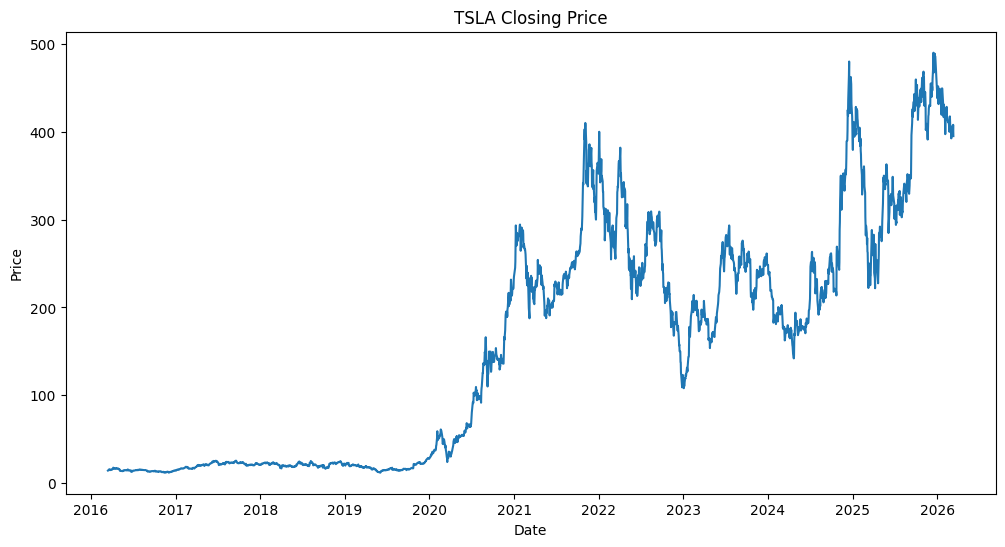

In [6]:
plt.figure(figsize=(12,6))
plt.plot(data['Date'], data['Close'])
plt.title(f"{stock} Closing Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

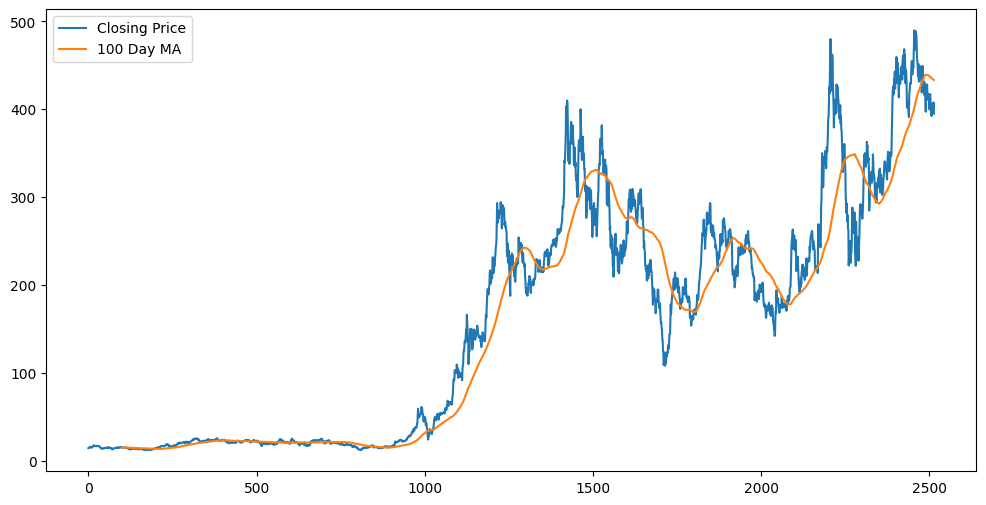

In [7]:
ma_100_days = data['Close'].rolling(100).mean()

plt.figure(figsize=(12,6))
plt.plot(data['Close'], label="Closing Price")
plt.plot(ma_100_days, label="100 Day MA")
plt.legend()
plt.show()

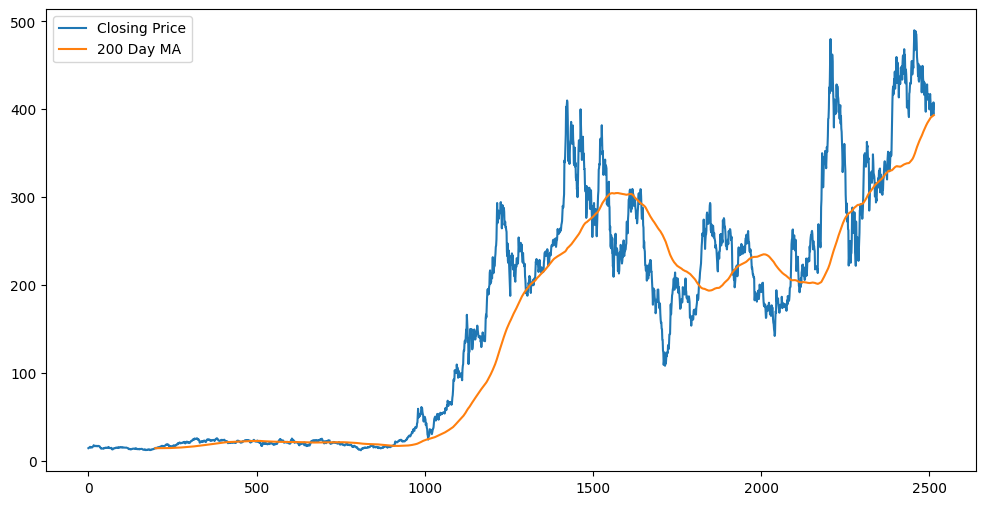

In [8]:
ma_200_days = data['Close'].rolling(200).mean()

plt.figure(figsize=(12,6))
plt.plot(data['Close'], label="Closing Price")
plt.plot(ma_200_days, label="200 Day MA")
plt.legend()
plt.show()

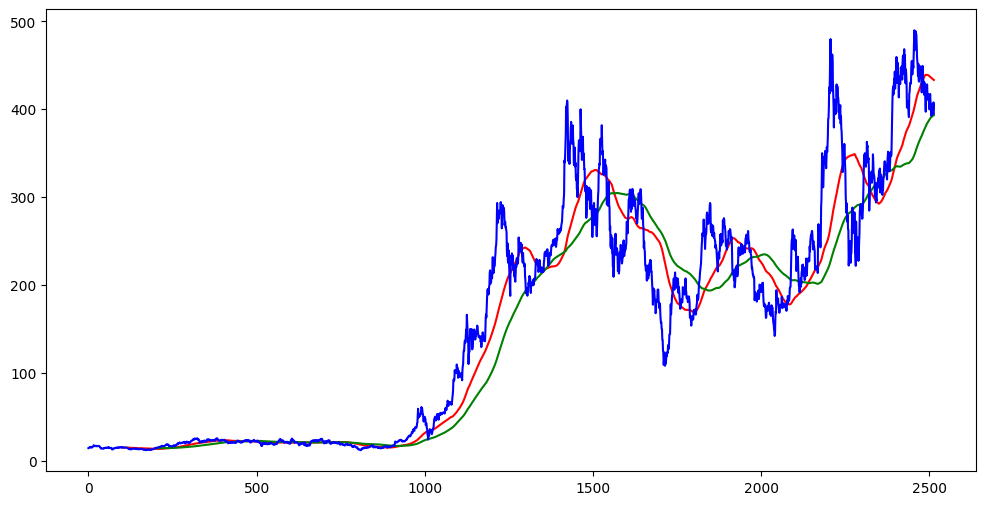

In [9]:
plt.figure(figsize=(12,6))
plt.plot(ma_100_days, 'r')
plt.plot(ma_200_days, 'g')
plt.plot(data.Close, 'b')
plt.show()

In [10]:
data.dropna(inplace=True) # This line will remove any rows with missing values

In [11]:
data_train = pd.DataFrame(data['Close'][0:int(len(data)*0.8)]) # Split the data into training and testing sets in 80:20 ratio
data_test = pd.DataFrame(data['Close'][int(len(data)*0.8):])   # Split the data into training and testing sets in 80:20 ratio

In [12]:
data_train.shape[0], data_test.shape[0]

(2011, 503)

In [13]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0,1))

In [14]:
data_train_scale = scaler.fit_transform(data_train)

In [15]:
data_training_array = scaler.fit_transform(data_train)

In [16]:
# Preparing the data to be used in LSTM Neural Network
x_train = []  # Input data for LSTM
y_train = []  # Output data for LSTM


In [17]:
# Use the last 100 days of data to predict the stock price on the 101th day 
for i in range(100, data_training_array.shape[0]):
    x_train.append(data_training_array[i-100:i])
    y_train.append(data_training_array[i])

In [18]:
x_train, y_train = np.array(x_train), np.array(y_train)

In [19]:
from tensorflow.keras.layers import Dense, Dropout, LSTM
from tensorflow.keras.models import Sequential

In [ ]:
# In this step, we are creating the LSTM model
model = Sequential()

# This is the first LSTM Layer
model.add(LSTM(units=50, activation='relu', return_sequences=True, 
            input_shape=(x_train.shape[1],1)))
model.add(Dropout(0.2))

# Second LSTM Layer
model.add(LSTM(units=60, activation='relu', return_sequences=True))
model.add(Dropout(0.3))

# Third LSTM Layer
model.add(LSTM(units=80, activation='relu', return_sequences=True))
model.add(Dropout(0.4))

# Fourth LSTM Layer
model.add(LSTM(units=120, activation='relu'))
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(units=1))

C:\Users\Ishaan\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [21]:
# Compiling the model
model.compile(optimizer='adam', loss='mean_squared_error')

In [22]:
# Training the model
model.fit(x_train, y_train, epochs=50)

Epoch 1/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 8s 82ms/step - loss: 0.0382
Epoch 2/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - loss: 0.0091
Epoch 3/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 78ms/step - loss: 0.0082
Epoch 4/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 6s 96ms/step - loss: 0.0076
Epoch 5/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 79ms/step - loss: 0.0074
Epoch 6/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 80ms/step - loss: 0.0062
Epoch 7/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 84ms/step - loss: 0.0060
Epoch 8/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - loss: 0.0068
Epoch 9/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 7s 117ms/step - loss: 0.0060
Epoch 10/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 6s 91ms/step - loss: 0.0058
Epoch 11/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 85ms/step - loss: 0.0053
Epoch 12/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 8s 134ms/step - loss: 0.0054
Epoch 13/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 9s 142ms/step - loss: 0.0054
Epoch 14/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 8s 140ms/step - loss: 0.0052
Epoch 15/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 8s 136ms/step - loss: 0.0053

In [23]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 100, 50)        │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100, 50)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 100, 60)        │        26,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100, 60)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 100, 80)        │        45,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 100, 80)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 120)            │        96,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           121 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 536,285 (2.05 MB)

 Trainable params: 178,761 (698.29 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 357,524 (1.36 MB)

In [26]:
past_100_days = data_train.tail(100)

final_df = pd.concat([past_100_days, data_test], ignore_index=True)

In [27]:
input_data = scaler.fit_transform(final_df)

In [28]:
# This step is creating test sequences
x_test = []
y_test = []

for i in range(100, input_data.shape[0]):
    x_test.append(input_data[i-100:i])
    y_test.append(input_data[i])

In [29]:
x_test, y_test = np.array(x_test), np.array(y_test)

In [30]:
y_predicted = model.predict(x_test)

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step


In [33]:
y_predicted

array([[ 66.44852937],
       [ 65.45085559],
       [ 63.95528566],
       [ 62.00864862],
       [ 59.67136351],
       [ 56.95313307],
       [ 53.98527037],
       [ 50.95351596],
       [ 48.06853576],
       [ 45.46513625],
       [ 43.17884997],
       [ 41.22174571],
       [ 39.59803472],
       [ 38.31698173],
       [ 37.35709254],
       [ 36.67101981],
       [ 36.17819269],
       [ 35.81142823],
       [ 35.52512575],
       [ 35.2762632 ],
       [ 35.05158744],
       [ 34.86058868],
       [ 34.70472078],
       [ 34.58970585],
       [ 34.50933974],
       [ 34.42964743],
       [ 34.31021652],
       [ 34.12192851],
       [ 33.84150364],
       [ 33.44387399],
       [ 32.87570576],
       [ 32.12331304],
       [ 31.22586172],
       [ 30.28881951],
       [ 29.42470311],
       [ 28.79687772],
       [ 28.52214905],
       [ 28.58958858],
       [ 28.9392826 ],
       [ 29.4992875 ],
       [ 30.22079429],
       [ 31.06464748],
       [ 31.9798275 ],
       [ 32

In [ ]:
# This is converting the value back to the original scale from the scaled values (values between 0 and 1)
scale_factor = 1/scaler.scale_[0]
y_predicted = y_predicted * scale_factor
y_test = y_test * scale_factor

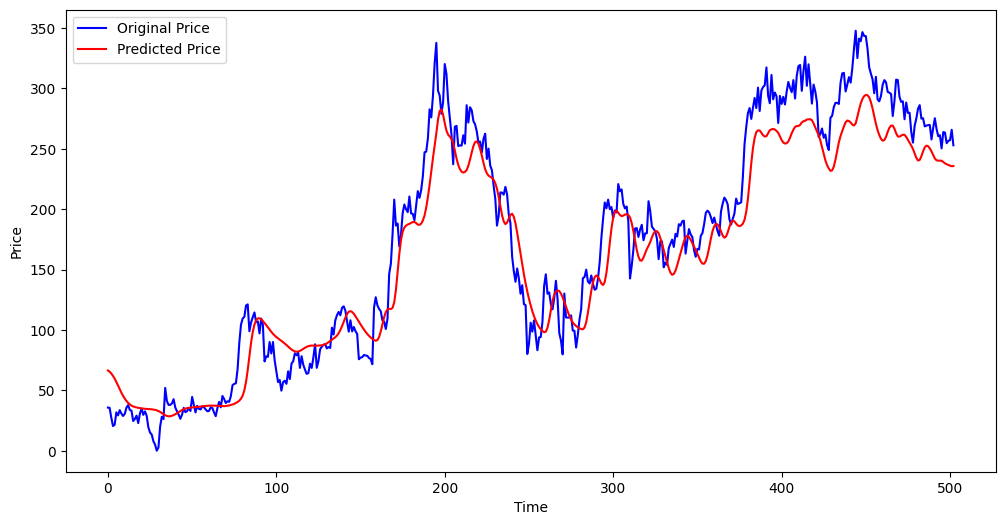

In [32]:
plt.figure(figsize=(12,6))
plt.plot(y_test, 'b', label='Original Price')
plt.plot(y_predicted, 'r', label='Predicted Price')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()

In [ ]:
model.save('Stock Price Prediction Model.keras')
